In [2]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Vergleich der Wetterdaten:

1) Absolute Abweichung zwischen den einzelnen Werten

- gemittelter:

    2) Median
    3) Arithmetisches Mittel
    4) Korrelation


In [3]:
n = pypsa.Network('/Users/mick/Documents/GitHub/masterthesis-mick/base_s_1__none_2035_lt.nc')

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


In [4]:
forecast_onwind = pd.read_pickle('/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten/cappacity_factors_prepared/cf_onwind.pkl')
forecast_offwind = pd.read_pickle('/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten/cappacity_factors_prepared/cf_offwind.pkl')
forecast_solar = pd.read_pickle('/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten/cappacity_factors_prepared/cf_solar.pkl')

historic_onwind = n.generators_t.p_max_pu['DE0 0 onwind-2035']
historic_offwind = n.generators_t.p_max_pu['DE0 0 offwind-dc-2035']
historic_solar = n.generators_t.p_max_pu['DE0 0 solar-2035']



In [5]:
def get_mean_corr(forecast, historic):
    df = pd.DataFrame()
    liste = []

    for i in forecast:
        df = pd.concat([df, i], axis=1)

    liste.append(df.corrwith(historic).values)
    return np.mean(liste)

In [14]:
def get_sum(forecast):
    df = pd.DataFrame()

    for i in forecast:
        df = pd.concat([df, i], axis=1)

    df = df.sum(axis=0)
    return df.mean()

In [16]:
print('Forecast onwind sum:', get_sum(forecast_onwind).round(2))
print('Forecast offwind sum:', get_sum(forecast_offwind).round(2))
print('Forecast solar sum:', get_sum(forecast_solar).round(2))

Forecast onwind sum: 709.46
Forecast offwind sum: 1622.8
Forecast solar sum: 329.9


# Korrelation

In [7]:
print('Mean Corr on-wind:', get_mean_corr(forecast_onwind, historic_onwind).round(3))
print('Mean Corr off-wind:', get_mean_corr(forecast_offwind, historic_offwind).round(3))
print('Mean Corr solar:', get_mean_corr(forecast_solar, historic_solar).round(3))

Mean Corr on-wind: 0.827
Mean Corr off-wind: 0.657
Mean Corr solar: 0.883


# Sum

In [9]:
print('Historic onwind sum:', historic_onwind.sum().round(2))
print('Historic offwind sum:', historic_offwind.sum().round(2))
print('Historic solar sum:', historic_solar.sum().round(2))

Historic onwind sum: 716.67
Historic offwind sum: 1633.57
Historic solar sum: 319.44


# Abweichung

In [74]:
def plot_abweichung(forecast_data, historic_data, title,start='2019-01-01', steps=10,):
    df = pd.DataFrame()

    for i in forecast_data:
        df = pd.concat([df, i], axis=1)

    diffs = df.subtract(historic_data.values, axis=0)

    # Enddatum berechnen: x * 6 Tage nach start
    end = pd.to_datetime(start) + pd.Timedelta(days=steps*6 - 1)

    fig, ax = plt.subplots(figsize=(32,4))

    diffs.loc[start:end].plot(
        ax = ax,
        ylim=(-1,1),
        legend=False)

    # Horizontale Linie bei y=0
    plt.axhline(y=0, color="black", linestyle="--", linewidth=1)

    # Vertikale Linien im 6-Tages-Rhythmus
    for day in pd.date_range(start=df.index.min(), end=df.index.max(), freq="6D"):
        plt.axvline(x=day, color="black", linestyle="--", linewidth=1)
    plt.grid()
    plt.title(title)
    plt.ylabel('Error')
    plt.xlabel('Date')


### 1. On-Wind

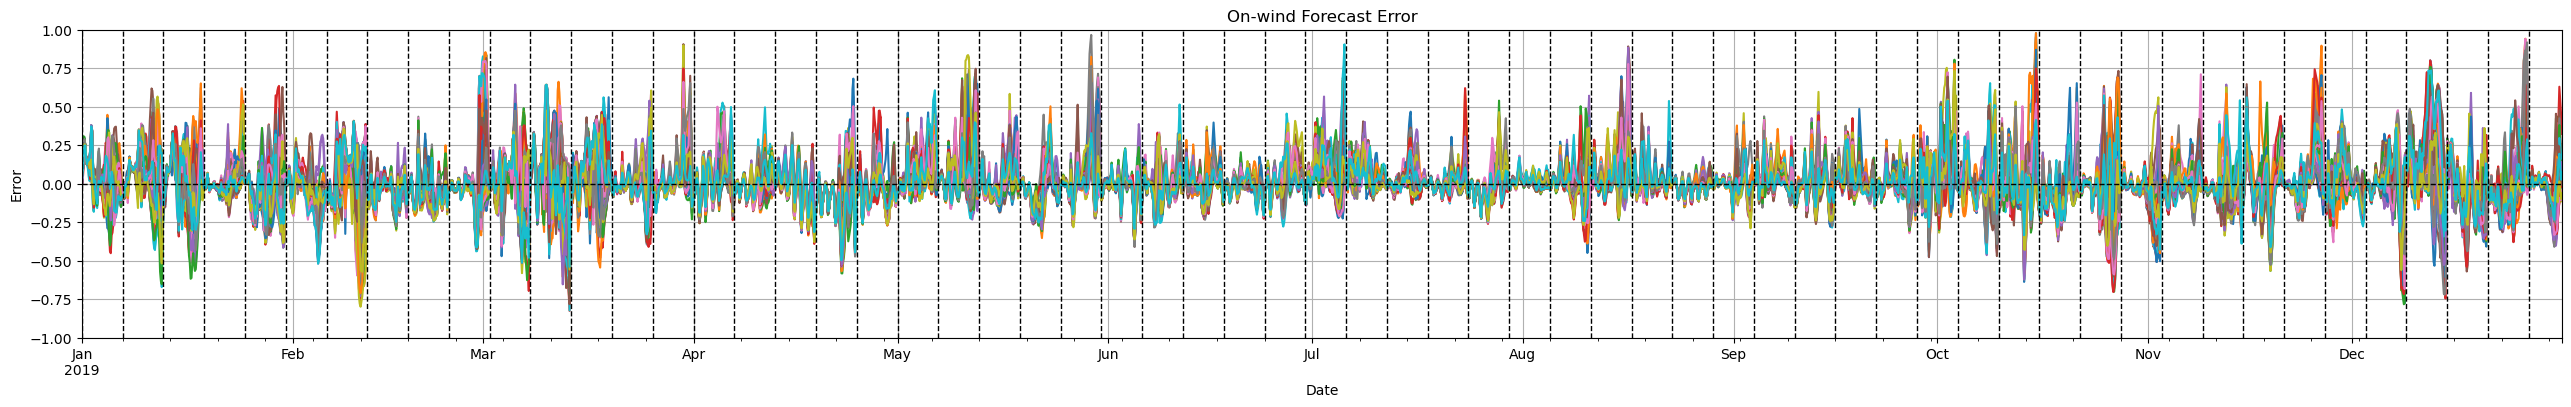

In [80]:
plot_abweichung(forecast_onwind, historic_onwind, steps=70,title='On-wind Forecast Error')

### 2. Off-Wind

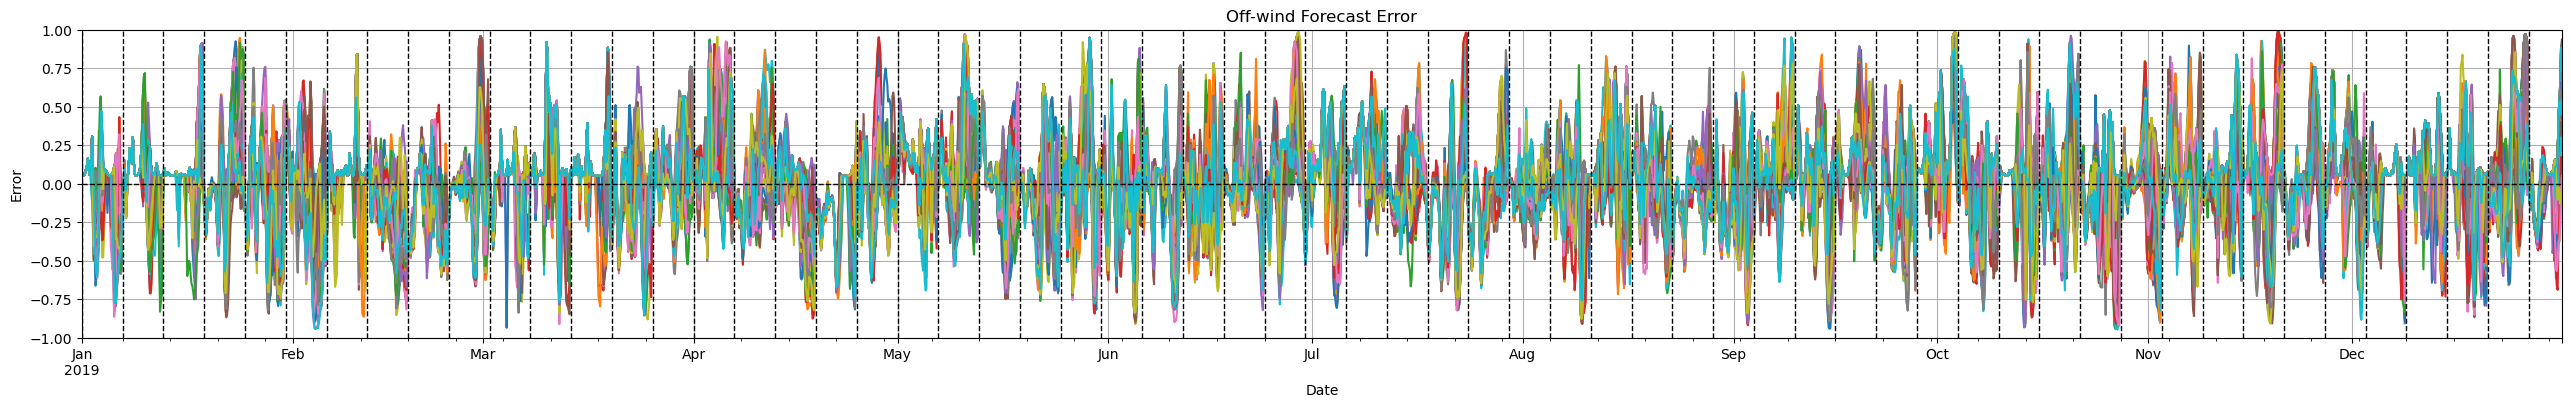

In [76]:
plot_abweichung(forecast_offwind, historic_offwind, start='2019-01-01', steps=70 ,title='Off-wind Forecast Error')

### 3. Solar

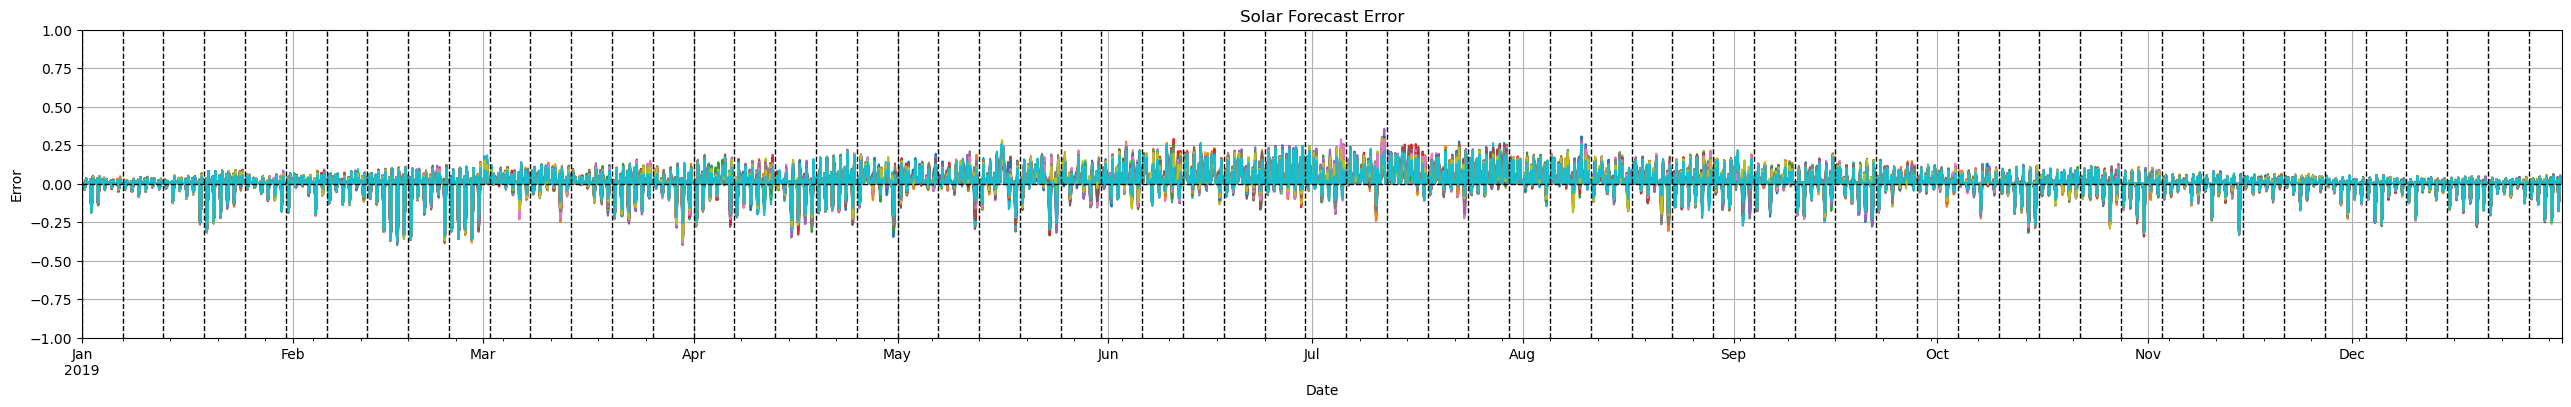

In [77]:
plot_abweichung(forecast_solar, historic_solar, start='2019-01-01', steps=70,title='Solar Forecast Error')

# CF Plot

In [28]:
def plot_cf(forecast, historic):
    fig, ax = plt.subplots(2, 1, figsize=(16,9))

    for i in range(0,50):
        forecast[i].plot(
            ax=ax[0],
            legend=False,
            ylim=(0,1),
            xlabel='Date',
            ylabel='capacity factor',
            title='Forecast'
        )

    historic.plot(
        ax=ax[1],
        label='real_cf',
        ylim=(0,1),
        xlabel='Date',
        ylabel='capacity factor',
        title='Historic'
    )

    plt.tight_layout()

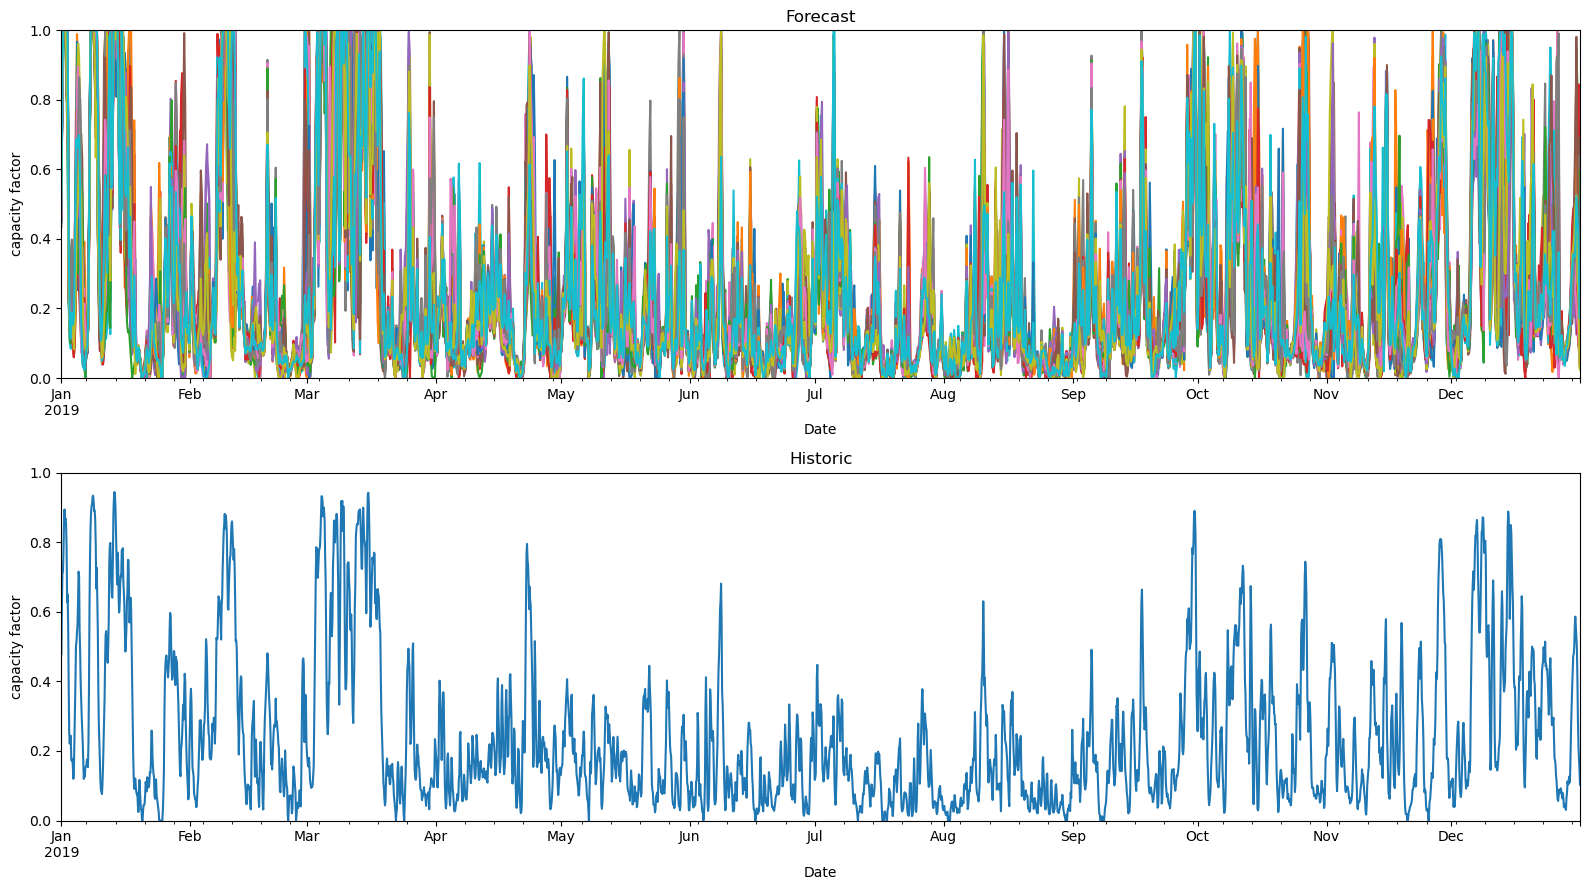

In [ ]:
plot_cf(forecast_onwind, historic_onwind)

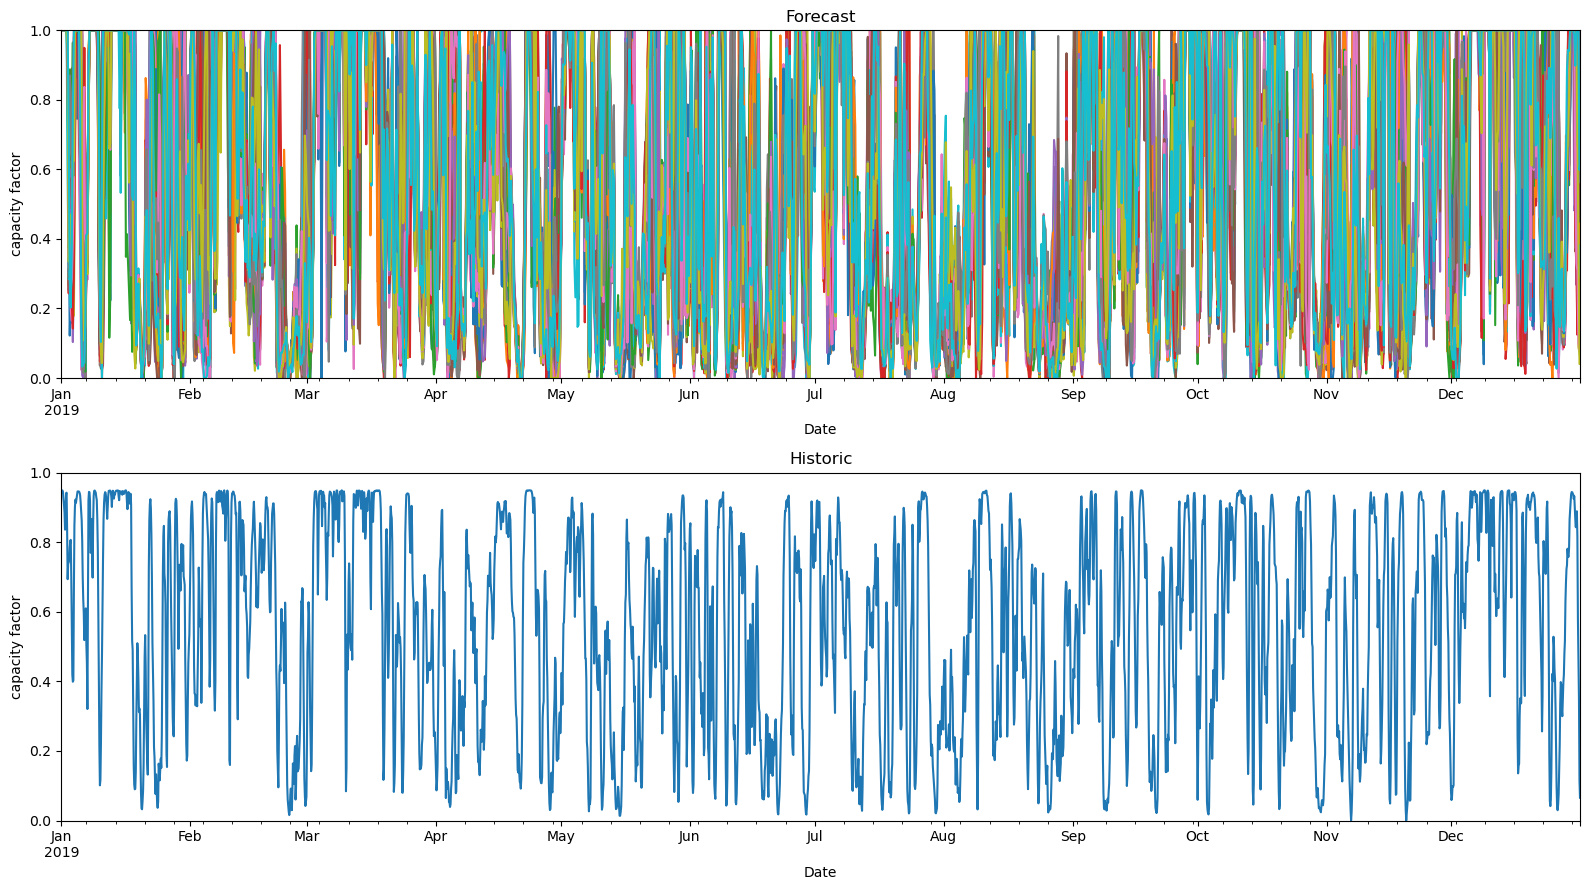

In [26]:
plot_cf(forecast_offwind, historic_offwind)

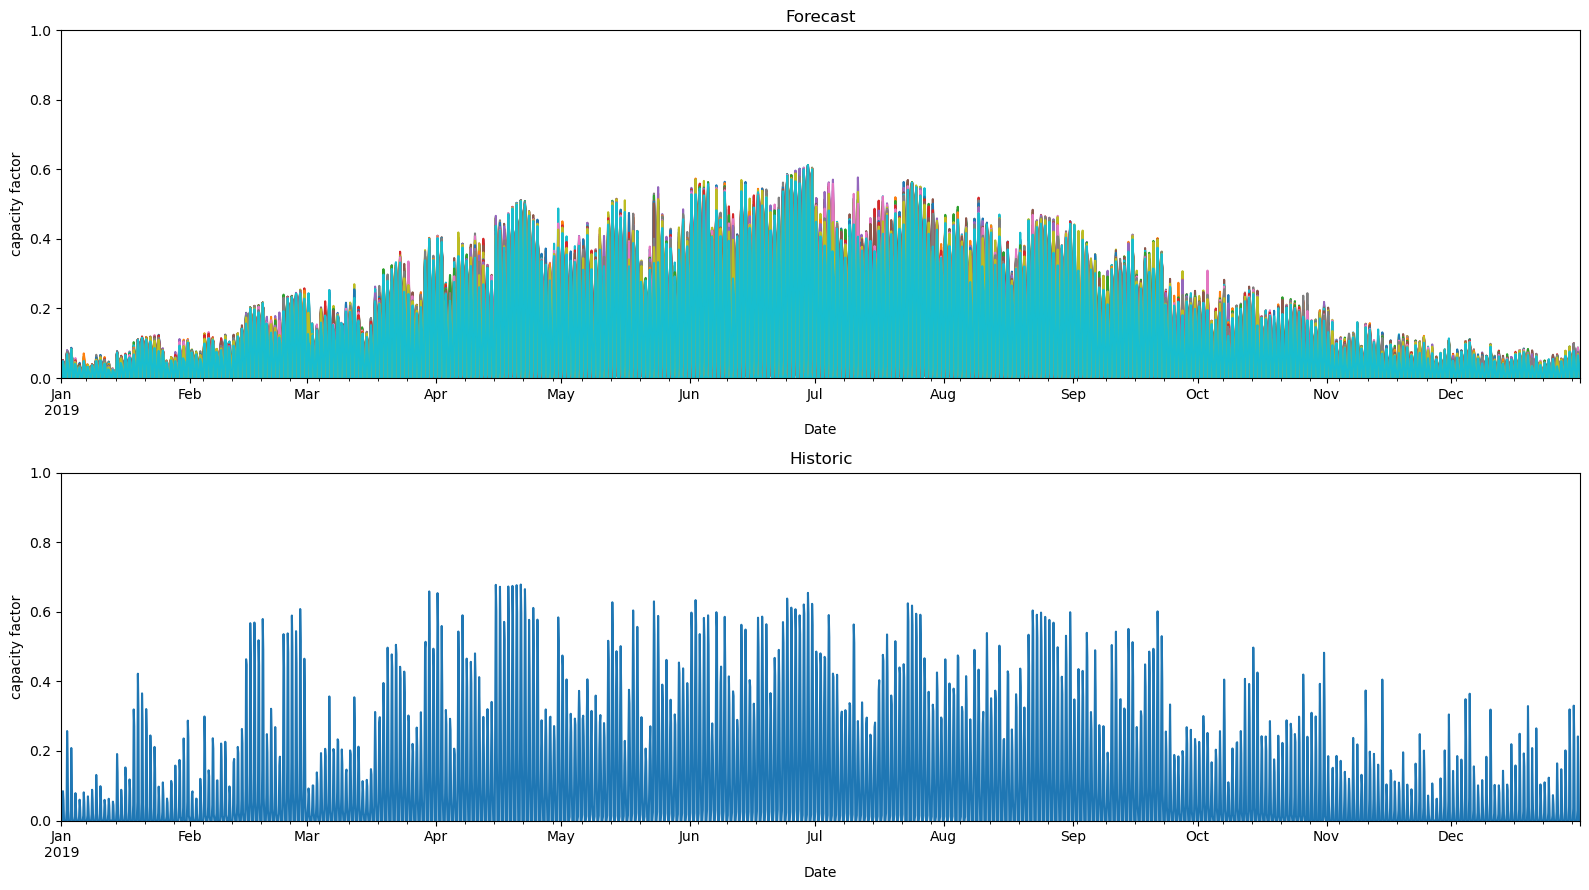

In [29]:
plot_cf(forecast_solar, historic_solar)

# TESTUMGEBUNG